In [1]:
rows=10
columns=7

In [2]:
import numpy as np

In [3]:
wind=[[0]*rows]*columns

In [4]:
for i in range(len(wind)):
    for j in range(len(wind[i])):
        if j == 3 or j == 4 or j == 5 or j == 8:
            wind[i][j] = 1
        if j == 6 or j == 7:
            wind[i][j] = 2
wind

[[0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]]

In [5]:
agent_pos=(5,4)
dxdy = (1,0)
next_pos = tuple(map(lambda x,y: x+y, agent_pos, dxdy))
next_pos

(6, 4)

In [6]:
wind_dy=(0,wind[agent_pos[0]][agent_pos[1]])
wind_dy

(0, 1)

In [7]:
final_pos = tuple(map(lambda x,y: x+y, next_pos, wind_dy))
final_pos

(6, 5)

In [8]:
from enum import IntEnum
#from platform import win32_edition
from typing import Tuple, Optional, List
from gym import Env, spaces
from gym.utils import seeding
from gym.envs.registration import register


def register_env() -> None:
    """Register custom gym environment so that we can use `gym.make()`

    In your main file, call this function before using `gym.make()` to use the Four Rooms environment.
        register_env()
        env = gym.make('WindyGridWorld-v0')

    There are a couple of ways to create Gym environments of the different variants of Windy Grid World.
    1. Create separate classes for each env and register each env separately.
    2. Create one class that has flags for each variant and register each env separately.

        Example:
        (Original)     register(id="WindyGridWorld-v0", entry_point="env:WindyGridWorldEnv")
        (King's moves) register(id="WindyGridWorldKings-v0", entry_point="env:WindyGridWorldEnv", **kwargs)

        The kwargs will be passed to the entry_point class.

    3. Create one class that has flags for each variant and register env once. You can then call gym.make using kwargs.

        Example:
        (Original)     gym.make("WindyGridWorld-v0")
        (King's moves) gym.make("WindyGridWorld-v0", **kwargs)

        The kwargs will be passed to the __init__() function.

    Choose whichever method you like.
    """
    register(id="WindyGridWorld-v0", entry_point="env:WindyGridWorldEnv")


class Action(IntEnum):
    """Action"""

    LEFT = 0
    DOWN = 1
    RIGHT = 2
    UP = 3


def actions_to_dxdy(action: Action) -> Tuple[int, int]:
    """
    Helper function to map action to changes in x and y coordinates
    Args:
        action (Action): taken action
    Returns:
        dxdy (Tuple[int, int]): Change in x and y coordinates
    """
    mapping = {
        Action.LEFT: (-1, 0),
        Action.DOWN: (0, -1),
        Action.RIGHT: (1, 0),
        Action.UP: (0, 1),
    }
    return mapping[action]


class WindyGridWorldEnv(Env):
    def __init__(self):
        """Windy grid world gym environment
        This is the template for Q4a. You can use this class or modify it to create the variants for parts c and d.
        """

        # Grid dimensions (x, y)
        self.rows = 10
        self.cols = 7

        # Wind
        # TODO define self.wind as either a dict (keys would be states) or multidimensional array (states correspond to indices)
        self.wind = [[0]*self.rows]*self.columns
        for i in range(len(self.wind)):
            for j in range(len(self.wind[i])):
                if j == 3 or j == 4 or j == 5 or j == 8:
                    self.wind[i][j] = 1
                if j == 6 or j == 7:
                    self.wind[i][j] = 2

        self.action_space = spaces.Discrete(len(Action))
        self.observation_space = spaces.Tuple(
            (spaces.Discrete(self.rows), spaces.Discrete(self.cols))
        )

        # Set start_pos and goal_pos
        self.start_pos = (0, 3)
        self.goal_pos = (7, 3)
        self.agent_pos = None

    def seed(self, seed: Optional[int] = None) -> List[int]:
        """Fix seed of environment

        In order to make the environment completely reproducible, call this function and seed the action space as well.
            env = gym.make(...)
            env.seed(seed)
            env.action_space.seed(seed)

        This function does not need to be used for this assignment, it is given only for reference.
        """

        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def reset(self):
        self.agent_pos = self.start_pos
        return self.agent_pos

    def step(self, action: Action) -> Tuple[Tuple[int, int], float, bool, dict]:
        """Take one step in the environment.

        Takes in an action and returns the (next state, reward, done, info).
        See https://github.com/openai/gym/blob/master/gym/core.py#L42-L58 foand r more info.

        Args:
            action (Action): an action provided by the agent

        Returns:
            observation (object): agent's observation after taking one step in environment (this would be the next state s')
            reward (float) : reward for this transition
            done (bool): whether the episode has ended, in which case further step() calls will return undefined results
            info (dict): contains auxiliary diagnostic information (helpful for debugging, and sometimes learning). Not used in this assignment.
        """
        # Check if goal was reached
        print(f"agent pos: {self.agent_pos}")
        if self.agent_pos == self.goal_pos:
            done = True
            reward = 0.0
        else:
            done = False
            reward = -1.0
        print(f"change from action: {actions_to_dxdy(action)}")
        next_pos = tuple(map(lambda x,y: x + y, self.agent_pos, actions_to_dxdy(action)))
        
        #add the wind change to next pos
        print(f"wind value: {self.wind[self.agent_pos[0]][self.agent_pos[1]]}")
        wind_dy = (0,self.wind[self.agent_pos[0]][self.agent_pos[1]])
        self.agent_pos = tuple(map(lambda x,y: x+y, next_pos, wind_dy))

        return self.agent_pos, reward, done, {}

In [9]:
register_env()

In [10]:
import gym

In [11]:
env=gym.make('WindyGridWorld-v0')

In [12]:
env.reset()

(0, 3)

In [13]:
action = Action(2)
action

<Action.RIGHT: 2>

In [14]:
env.step(action)

((1, 3), -1.0, False, {})

In [15]:
env.wind[3][0]

0

In [16]:
env.step(Action(2))

((2, 3), -1.0, False, {})

In [17]:
env.step(Action(2))

((3, 3), -1.0, False, {})

In [18]:
env.step(Action(2))

((4, 4), -1.0, False, {})

In [19]:
env.step(Action(2))

((5, 5), -1.0, False, {})

In [20]:
env.step(Action(2))

((6, 6), -1.0, False, {})

In [21]:
env.step(Action(2))

((7, 6), -1.0, False, {})

In [22]:
env.step(Action(2))

((8, 6), -1.0, False, {})

In [23]:
env.step(Action(2))

((9, 6), -1.0, False, {})

In [24]:
env.step(Action(2))

((9, 6), -1.0, False, {})

In [25]:
env.step(Action(1))

((9, 5), -1.0, False, {})

In [26]:
env.step(Action(1))

((9, 4), -1.0, False, {})

In [27]:
env.step(Action(1))

((9, 3), -1.0, False, {})

In [28]:
env.step(Action(1))

((9, 2), -1.0, False, {})

In [29]:
env.step(Action(0))

((8, 2), -1.0, False, {})

In [30]:
env.step(Action(1))

((8, 2), -1.0, False, {})

In [31]:
env.step(Action(0))

((7, 3), -1.0, False, {})

In [32]:
env.step(Action(1))

((0, 3), 0.0, True, {})

In [33]:
p=[0.123, 0.5, 0.5453, 0.012, 0.0034, 0.6]

In [34]:
max_p=[_ for _ in range(len(p)) if p[_] == max(p)]
max_p

[5]

In [35]:
import numpy as np

In [36]:
greedy=np.random.choice(max_p)

In [37]:
exp=np.random.choice([0,1,2,3])
np.random.choice([greedy,exp],p=[0.9,0.1])

5

In [38]:
q=[3.3423423,-2.32312,3.6212,0.2121]
max_a = np.random.choice([a for a in range(len(q)) if q[a] == max(q)])
print(f"max_a: {max_a}")
pi_Q = 0
epsilon=0.1
for a in range(len(q)):
    if a == max_a:
        pi_Q+=((1-epsilon) + (epsilon/4))*q[a]
        print(f"max prob value: {((1-epsilon) + (epsilon/4))}")
    else:
        pi_Q+=(epsilon/4)*q[a]
        print(f"other prob value: {(epsilon/4)}")
pi_Q

max_a: 2
other prob value: 0.025
other prob value: 0.025
max prob value: 0.925
other prob value: 0.025


3.3803930575

In [39]:
from math import exp
import gym
from typing import Optional
from collections import defaultdict
from typing import Tuple
import numpy as np

def egreedy_action(Q: defaultdict, state: Tuple[int, int], epsilon:float):
    greedy_action = np.random.choice([a for a in range(len(Q[state])) if Q[state][a] == max(Q[state])])
    exp_action = np.random.choice([0,1,2,3])
    action = np.random.choice([greedy_action, exp_action], p=[1-epsilon, epsilon])
    return action

def sarsa(env: gym.Env, num_steps: int, gamma: float, epsilon: float, step_size: float):
    """SARSA algorithm.

    Args:
        env (gym.Env): a Gym API compatible environment
        num_steps (int): Number of steps
        gamma (float): Discount factor of MDP
        epsilon (float): epsilon for epsilon greedy
        step_size (float): step size
    """
    # TODO
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    num_episodes = 0
    eps_perstep=[]
    #initial vals
    S = env.reset()
    #print(f"initisl state, from reset: {S}")
    A = egreedy_action(Q,S,epsilon)
    #print(f"initial action: {A}")
    for t in range(num_steps):
        #print(f"time step: {t}")
        S_prime, reward, done, _ = env.step(A)
        #print(f"Next State: {S_prime}, reward: {reward}, is done?: {done}")
        if done:
            num_episodes+=1
            #print(f"epsiode completed step: {t}")
            #print(f"number of episodes completed: {num_episodes}")
        eps_perstep.append(num_episodes)
        A_prime = egreedy_action(Q,S_prime,epsilon)
        #print(f"Next Action from e-greedy: {A_prime}")
        #print(f"old Q(S,A): {Q[S][A]}")
        Q[S][A] = Q[S][A] + step_size*(reward + gamma*Q[S_prime][A_prime] - Q[S][A])
        #print(f"Update to Q(S,A): {Q[S][A] + step_size*(reward + gamma*Q[S_prime][A_prime])}")
        S=S_prime
        A=A_prime
    return eps_perstep, Q


In [190]:
epsilon=0.1
num_steps=10000
gamma=1
step_size=0.5

In [191]:
Q[(0,3)]

array([-13.72429705, -14.12420164, -13.70332882, -14.29813359])

In [192]:
import matplotlib.pyplot as plt


In [193]:
def q_learning(
    env: gym.Env,
    num_steps: int,
    gamma: float,
    epsilon: float,
    step_size: float,
):
    """Q-learning

    Args:
        env (gym.Env): a Gym API compatible environment
        num_steps (int): Number of steps
        gamma (float): Discount factor of MDP
        epsilon (float): epsilon for epsilon greedy
        step_size (float): step size
    """
    # TODO
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    num_episodes = 0
    eps_perstep = []
    #initial vals
    S = env.reset()
    for t in range(num_steps):
        A = egreedy_action(Q,S,epsilon)
        S_prime, reward, done, _ = env.step(A)
        if done:
            num_episodes+=1
            #print(f"epsiode completed step: {t}")
            #print(f"number of episodes completed: {num_episodes}")
        eps_perstep.append(num_episodes)
        A_prime = np.random.choice([a for a in range(len(Q[S_prime])) if Q[S_prime][a] == max(Q[S_prime])])
        Q[S][A] = Q[S][A] + step_size*(reward + gamma*Q[S_prime][A_prime] - Q[S][A])
        S=S_prime
    return eps_perstep, Q

In [194]:
def exp_sarsa(
    env: gym.Env,
    num_steps: int,
    gamma: float,
    epsilon: float,
    step_size: float,
):
    """Expected SARSA

    Args:
        env (gym.Env): a Gym API compatible environment
        num_steps (int): Number of steps
        gamma (float): Discount factor of MDP
        epsilon (float): epsilon for epsilon greedy
        step_size (float): step size
    """
    # TODO
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    num_episodes = 0
    eps_perstep = []
    #initial vals
    S = env.reset()
    A = egreedy_action(Q,S,epsilon)
    for t in range(num_steps):
        S_prime, reward, done, _ = env.step(A)
        if done:
            num_episodes+=1
            #rint(f"epsiode completed step: {t}")
            #print(f"number of episodes completed: {num_episodes}")
        eps_perstep.append(num_episodes)
        #A_prime = egreedy_action(S_prime)
        max_a = np.random.choice([a for a in range(len(Q[S_prime])) if Q[S_prime][a] == max(Q[S_prime])])
        pi_Q = 0
        for a in range(len(Q[S])):
            if a == max_a:
                pi_Q+=((1-epsilon) + (epsilon/4))*Q[S][a]
            else:
                pi_Q+=(epsilon/4)*Q[S][a]
        Q[S][A] = Q[S][A] + step_size*(reward + gamma*pi_Q - Q[S][A])
        S=S_prime
        A=egreedy_action(Q,S,epsilon)
    return eps_perstep, Q

In [231]:
#started rewrite for this exercise, needs work
def on_policy_mc_control_es(
    env: gym.Env, num_steps: int, gamma: float, epsilon: float):
    """On-policy Monte Carlo control with exploring starts for Blackjack

    Args:
        env (gym.Env): a Gym API compatible environment
        num_episodes (int): Number of episodes
        gamma (float): Discount factor of MDP
    """
    # We use defaultdicts here for both Q and N for convenience. The states will be the keys and the values will be numpy arrays with length = num actions
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    N = defaultdict(lambda: np.zeros(env.action_space.n))

    # If the state was seen, use the greedy action using Q values.
    # Else, default to the original policy of sticking to 20 or 21.
    S = env.reset()
    eps_per_step=[]
    num_episodes=0
    episodes=[]
    done = False
    t = 0
    #generating num_step length time steps episodes
    while True:
        # TODO Q3b
        # Note there is no need to update the policy here directly.
        # By updating Q, the policy will automatically be updated.
        episode=[]
        while not done:
            print(f"time step: {t}")
            A = egreedy_action(Q,S,epsilon)
            S_prime, R, done, _ = env.step(A)
            print(f"step: {(S,A,R)}")
            episode.append((S, A, R))
            S=S_prime 
            eps_per_step.append(num_episodes)
            t+=1
            if t == num_steps:
                break
        num_episodes+=1
        print(f"num_episodes: {num_episodes}")
        G = 0
        for t in range(len(episode) - 1, -1, -1):
            G = gamma*G + episode[t][2]
            N[episode[t][0]][episode[t][1]]+=1
            first_visit = True
            for t_ in range(t):
                if episode[t][:2] == episode[t_][:2]:
                    first_visit = False
            if first_visit:
                Old_Q = Q[episode[t][0]][episode[t][1]]
                Q[episode[t][0]][episode[t][1]] = Old_Q + (G - Old_Q) / (N[episode[t][0]][episode[t][1]])

    return eps_per_step, Q


In [232]:
temp_MC, Q = on_policy_mc_control_es(env,num_steps,gamma,epsilon)

time step: 0
step: ((0, 3), 0, -1.0)
time step: 1
step: ((0, 3), 1, -1.0)
time step: 2
step: ((0, 2), 3, -1.0)
time step: 3
step: ((0, 3), 1, -1.0)
time step: 4
step: ((0, 2), 3, -1.0)
time step: 5
step: ((0, 3), 2, -1.0)
time step: 6
step: ((1, 3), 2, -1.0)
time step: 7
step: ((2, 3), 1, -1.0)
time step: 8
step: ((2, 2), 1, -1.0)
time step: 9
step: ((2, 1), 1, -1.0)
time step: 10
step: ((2, 0), 2, -1.0)
time step: 11
step: ((3, 0), 2, -1.0)
time step: 12
step: ((4, 1), 3, -1.0)
time step: 13
step: ((4, 3), 3, -1.0)
time step: 14
step: ((4, 5), 1, -1.0)
time step: 15
step: ((4, 5), 1, -1.0)
time step: 16
step: ((4, 5), 1, -1.0)
time step: 17
step: ((4, 5), 3, -1.0)
time step: 18
step: ((4, 5), 0, -1.0)
time step: 19
step: ((3, 6), 1, -1.0)
time step: 20
step: ((3, 6), 2, -1.0)
time step: 21
step: ((4, 6), 0, -1.0)
time step: 22
step: ((3, 6), 0, -1.0)
time step: 23
step: ((2, 6), 0, -1.0)
time step: 24
step: ((1, 6), 2, -1.0)
time step: 25
step: ((2, 6), 3, -1.0)
time step: 26
step: ((

step: ((9, 6), 0, -1.0)
time step: 213
step: ((8, 6), 2, -1.0)
time step: 214
step: ((9, 6), 0, -1.0)
time step: 215
step: ((8, 6), 1, -1.0)
time step: 216
step: ((8, 6), 2, -1.0)
time step: 217
step: ((9, 6), 3, -1.0)
time step: 218
step: ((9, 6), 2, -1.0)
time step: 219
step: ((9, 6), 1, -1.0)
time step: 220
step: ((9, 5), 0, -1.0)
time step: 221
step: ((8, 5), 1, -1.0)
time step: 222
step: ((8, 5), 3, -1.0)
time step: 223
step: ((8, 5), 1, -1.0)
time step: 224
step: ((8, 5), 3, -1.0)
time step: 225
step: ((8, 5), 2, -1.0)
time step: 226
step: ((9, 6), 3, -1.0)
time step: 227
step: ((9, 6), 1, -1.0)
time step: 228
step: ((9, 5), 1, -1.0)
time step: 229
step: ((9, 4), 3, -1.0)
time step: 230
step: ((9, 5), 1, -1.0)
time step: 231
step: ((9, 4), 1, -1.0)
time step: 232
step: ((9, 3), 0, -1.0)
time step: 233
step: ((8, 3), 3, -1.0)
time step: 234
step: ((8, 5), 0, -1.0)
time step: 235
step: ((7, 6), 2, -1.0)
time step: 236
step: ((8, 6), 1, -1.0)
time step: 237
step: ((8, 6), 3, -1.0)
t

step: ((6, 6), 0, -1.0)
time step: 423
step: ((5, 6), 3, -1.0)
time step: 424
step: ((5, 6), 3, -1.0)
time step: 425
step: ((5, 6), 0, -1.0)
time step: 426
step: ((4, 6), 1, -1.0)
time step: 427
step: ((4, 6), 3, -1.0)
time step: 428
step: ((4, 6), 3, -1.0)
time step: 429
step: ((4, 6), 0, -1.0)
time step: 430
step: ((3, 6), 2, -1.0)
time step: 431
step: ((4, 6), 1, -1.0)
time step: 432
step: ((4, 6), 3, -1.0)
time step: 433
step: ((4, 6), 0, -1.0)
time step: 434
step: ((3, 6), 1, -1.0)
time step: 435
step: ((3, 6), 3, -1.0)
time step: 436
step: ((3, 6), 0, -1.0)
time step: 437
step: ((2, 6), 0, -1.0)
time step: 438
step: ((1, 6), 3, -1.0)
time step: 439
step: ((1, 6), 0, -1.0)
time step: 440
step: ((0, 6), 1, -1.0)
time step: 441
step: ((0, 5), 2, -1.0)
time step: 442
step: ((1, 5), 3, -1.0)
time step: 443
step: ((1, 6), 3, -1.0)
time step: 444
step: ((1, 6), 0, -1.0)
time step: 445
step: ((0, 6), 3, -1.0)
time step: 446
step: ((0, 6), 2, -1.0)
time step: 447
step: ((1, 6), 1, -1.0)
t

step: ((9, 6), 3, -1.0)
time step: 633
step: ((9, 6), 0, -1.0)
time step: 634
step: ((8, 6), 2, -1.0)
time step: 635
step: ((9, 6), 0, -1.0)
time step: 636
step: ((8, 6), 1, -1.0)
time step: 637
step: ((8, 6), 1, -1.0)
time step: 638
step: ((8, 6), 2, -1.0)
time step: 639
step: ((9, 6), 0, -1.0)
time step: 640
step: ((8, 6), 2, -1.0)
time step: 641
step: ((9, 6), 2, -1.0)
time step: 642
step: ((9, 6), 2, -1.0)
time step: 643
step: ((9, 6), 0, -1.0)
time step: 644
step: ((8, 6), 0, -1.0)
time step: 645
step: ((7, 6), 1, -1.0)
time step: 646
step: ((7, 6), 1, -1.0)
time step: 647
step: ((7, 6), 0, -1.0)
time step: 648
step: ((6, 6), 3, -1.0)
time step: 649
step: ((6, 6), 1, -1.0)
time step: 650
step: ((6, 6), 2, -1.0)
time step: 651
step: ((7, 6), 1, -1.0)
time step: 652
step: ((7, 6), 1, -1.0)
time step: 653
step: ((7, 6), 0, -1.0)
time step: 654
step: ((6, 6), 2, -1.0)
time step: 655
step: ((7, 6), 0, -1.0)
time step: 656
step: ((6, 6), 1, -1.0)
time step: 657
step: ((6, 6), 1, -1.0)
t

num_episodes: 226
num_episodes: 227
num_episodes: 228
num_episodes: 229
num_episodes: 230
num_episodes: 231
num_episodes: 232
num_episodes: 233
num_episodes: 234
num_episodes: 235
num_episodes: 236
num_episodes: 237
num_episodes: 238
num_episodes: 239
num_episodes: 240
num_episodes: 241
num_episodes: 242
num_episodes: 243
num_episodes: 244
num_episodes: 245
num_episodes: 246
num_episodes: 247
num_episodes: 248
num_episodes: 249
num_episodes: 250
num_episodes: 251
num_episodes: 252
num_episodes: 253
num_episodes: 254
num_episodes: 255
num_episodes: 256
num_episodes: 257
num_episodes: 258
num_episodes: 259
num_episodes: 260
num_episodes: 261
num_episodes: 262
num_episodes: 263
num_episodes: 264
num_episodes: 265
num_episodes: 266
num_episodes: 267
num_episodes: 268
num_episodes: 269
num_episodes: 270
num_episodes: 271
num_episodes: 272
num_episodes: 273
num_episodes: 274
num_episodes: 275
num_episodes: 276
num_episodes: 277
num_episodes: 278
num_episodes: 279
num_episodes: 280
num_episod

...

num_episodes: 11033
num_episodes: 11034
num_episodes: 11035
num_episodes: 11036
num_episodes: 11037
num_episodes: 11038
num_episodes: 11039
num_episodes: 11040
num_episodes: 11041
num_episodes: 11042
num_episodes: 11043
num_episodes: 11044
num_episodes: 11045
num_episodes: 11046
num_episodes: 11047
num_episodes: 11048
num_episodes: 11049
num_episodes: 11050
num_episodes: 11051
num_episodes: 11052
num_episodes: 11053
num_episodes: 11054
num_episodes: 11055
num_episodes: 11056
num_episodes: 11057
num_episodes: 11058
num_episodes: 11059
num_episodes: 11060
num_episodes: 11061
num_episodes: 11062
num_episodes: 11063
num_episodes: 11064
num_episodes: 11065
num_episodes: 11066
num_episodes: 11067
num_episodes: 11068
num_episodes: 11069
num_episodes: 11070
num_episodes: 11071
num_episodes: 11072
num_episodes: 11073
num_episodes: 11074
num_episodes: 11075
num_episodes: 11076
num_episodes: 11077
num_episodes: 11078
num_episodes: 11079
num_episodes: 11080
num_episodes: 11081
num_episodes: 11082


num_episodes: 11442
num_episodes: 11443
num_episodes: 11444
num_episodes: 11445
num_episodes: 11446
num_episodes: 11447
num_episodes: 11448
num_episodes: 11449
num_episodes: 11450
num_episodes: 11451
num_episodes: 11452
num_episodes: 11453
num_episodes: 11454
num_episodes: 11455
num_episodes: 11456
num_episodes: 11457
num_episodes: 11458
num_episodes: 11459
num_episodes: 11460
num_episodes: 11461
num_episodes: 11462
num_episodes: 11463
num_episodes: 11464
num_episodes: 11465
num_episodes: 11466
num_episodes: 11467
num_episodes: 11468
num_episodes: 11469
num_episodes: 11470
num_episodes: 11471
num_episodes: 11472
num_episodes: 11473
num_episodes: 11474
num_episodes: 11475
num_episodes: 11476
num_episodes: 11477
num_episodes: 11478
num_episodes: 11479
num_episodes: 11480
num_episodes: 11481
num_episodes: 11482
num_episodes: 11483
num_episodes: 11484
num_episodes: 11485
num_episodes: 11486
num_episodes: 11487
num_episodes: 11488
num_episodes: 11489
num_episodes: 11490
num_episodes: 11491


num_episodes: 11851
num_episodes: 11852
num_episodes: 11853
num_episodes: 11854
num_episodes: 11855
num_episodes: 11856
num_episodes: 11857
num_episodes: 11858
num_episodes: 11859
num_episodes: 11860
num_episodes: 11861
num_episodes: 11862
num_episodes: 11863
num_episodes: 11864
num_episodes: 11865
num_episodes: 11866
num_episodes: 11867
num_episodes: 11868
num_episodes: 11869
num_episodes: 11870
num_episodes: 11871
num_episodes: 11872
num_episodes: 11873
num_episodes: 11874
num_episodes: 11875
num_episodes: 11876
num_episodes: 11877
num_episodes: 11878
num_episodes: 11879
num_episodes: 11880
num_episodes: 11881
num_episodes: 11882
num_episodes: 11883
num_episodes: 11884
num_episodes: 11885
num_episodes: 11886
num_episodes: 11887
num_episodes: 11888
num_episodes: 11889
num_episodes: 11890
num_episodes: 11891
num_episodes: 11892
num_episodes: 11893
num_episodes: 11894
num_episodes: 11895
num_episodes: 11896
num_episodes: 11897
num_episodes: 11898
num_episodes: 11899
num_episodes: 11900


num_episodes: 12260
num_episodes: 12261
num_episodes: 12262
num_episodes: 12263
num_episodes: 12264
num_episodes: 12265
num_episodes: 12266
num_episodes: 12267
num_episodes: 12268
num_episodes: 12269
num_episodes: 12270
num_episodes: 12271
num_episodes: 12272
num_episodes: 12273
num_episodes: 12274
num_episodes: 12275
num_episodes: 12276
num_episodes: 12277
num_episodes: 12278
num_episodes: 12279
num_episodes: 12280
num_episodes: 12281
num_episodes: 12282
num_episodes: 12283
num_episodes: 12284
num_episodes: 12285
num_episodes: 12286
num_episodes: 12287
num_episodes: 12288
num_episodes: 12289
num_episodes: 12290
num_episodes: 12291
num_episodes: 12292
num_episodes: 12293
num_episodes: 12294
num_episodes: 12295
num_episodes: 12296
num_episodes: 12297
num_episodes: 12298
num_episodes: 12299
num_episodes: 12300
num_episodes: 12301
num_episodes: 12302
num_episodes: 12303
num_episodes: 12304
num_episodes: 12305
num_episodes: 12306
num_episodes: 12307
num_episodes: 12308
num_episodes: 12309


num_episodes: 12669
num_episodes: 12670
num_episodes: 12671
num_episodes: 12672
num_episodes: 12673
num_episodes: 12674
num_episodes: 12675
num_episodes: 12676
num_episodes: 12677
num_episodes: 12678
num_episodes: 12679
num_episodes: 12680
num_episodes: 12681
num_episodes: 12682
num_episodes: 12683
num_episodes: 12684
num_episodes: 12685
num_episodes: 12686
num_episodes: 12687
num_episodes: 12688
num_episodes: 12689
num_episodes: 12690
num_episodes: 12691
num_episodes: 12692
num_episodes: 12693
num_episodes: 12694
num_episodes: 12695
num_episodes: 12696
num_episodes: 12697
num_episodes: 12698
num_episodes: 12699
num_episodes: 12700
num_episodes: 12701
num_episodes: 12702
num_episodes: 12703
num_episodes: 12704
num_episodes: 12705
num_episodes: 12706
num_episodes: 12707
num_episodes: 12708
num_episodes: 12709
num_episodes: 12710
num_episodes: 12711
num_episodes: 12712
num_episodes: 12713
num_episodes: 12714
num_episodes: 12715
num_episodes: 12716
num_episodes: 12717
num_episodes: 12718


In [195]:
from tqdm import trange
eps_pstep_expsarsa = [0]*num_steps
eps_perstep_Q = [0]*num_steps
eps_perstep_sarsa = [0]*num_steps
trials = 10
for _ in trange(trials, desc="trial"):
    temp_expsarsa,Qsarsa_exp = exp_sarsa(env,num_steps,gamma,epsilon,step_size)
    temp_q, Qq = q_learning(env,num_steps,gamma,epsilon,step_size)
    temp_sarsa,Q_sarsa=sarsa(env,num_steps,gamma,epsilon,step_size)
    eps_pstep_expsarsa = list(map(lambda x,y: x+y, eps_pstep_expsarsa, temp_expsarsa))
    eps_perstep_Q = list(map(lambda x,y: x+y, eps_perstep_Q, temp_q))
    eps_perstep_sarsa = list(map(lambda x,y: x+y, eps_perstep_sarsa, temp_sarsa))
eps_pstep_expsarsa = list(map(lambda x: x/trials, eps_pstep_expsarsa))
eps_perstep_Q = list(map(lambda x: x/trials, eps_perstep_Q))
eps_perstep_sarsa = list(map(lambda x: x/trials, eps_perstep_sarsa))

trial: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:29<00:00,  2.93s/it]


In [222]:
eps_per_step_MC = [0]*num_steps
for _ in trange(trials, desc="trial"):
    temp_MC, Q = on_policy_mc_control_es(env,num_steps,gamma,epsilon)
    eps_per_step_MC = list(map(lambda x,y: x+y, eps_per_step_MC, temp_MC))
eps_per_step_MC = list(map(lambda x: x/trials, eps_per_step_MC))

trial:   0%|                                                                                                                                                                                                                                                              | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [196]:
import matplotlib.pyplot as plt
#calculating the confidence bands
stderr_eps_sarsa = 1.96 * np.std(eps_perstep_sarsa) / np.sqrt(num_steps)
stderr_eps_qlearn = 1.96 * np.std(eps_perstep_Q) / np.sqrt(num_steps)
stderr_eps_expsarsa = 1.96 * np.std(eps_pstep_expsarsa) / np.sqrt(num_steps)


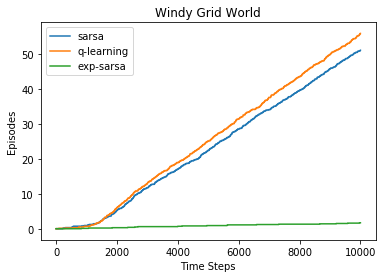

In [197]:
#sarsa and q-learning seem in the book to have a more exponential imporvement in time steps per episode
#my implementations seem more linear, possibly need improvement 
fig,ax = plt.subplots()

ax.plot(np.arange(0,num_steps,1),eps_perstep_sarsa)
ax.plot(np.arange(0,num_steps,1),eps_perstep_Q)
ax.plot(np.arange(0,num_steps,1),eps_pstep_expsarsa)

ax.fill_between(np.arange(0,num_steps,1), eps_perstep_sarsa-stderr_eps_sarsa, eps_perstep_sarsa+stderr_eps_sarsa, alpha=0.2)
ax.fill_between(np.arange(0,num_steps,1), eps_perstep_Q-stderr_eps_qlearn, eps_perstep_Q+stderr_eps_qlearn, alpha=0.2)
ax.fill_between(np.arange(0,num_steps,1), stderr_eps_expsarsa-stderr_eps_expsarsa, stderr_eps_expsarsa+stderr_eps_expsarsa, alpha=0.2)

plt.legend(['sarsa', 'q-learning', 'exp-sarsa'], loc='upper left')
plt.xlabel('Time Steps')
plt.ylabel('Episodes')
plt.title("Windy Grid World")
plt.savefig("q4_b_WindyGridWorld.pdf")
plt.show()

In [198]:
max_a = np.random.choice([a for a in range(len(Q[(3,4)])) if Q[(3,4)][a] == max(Q[(3,4)])])
max_a

1

In [199]:
Q[(3,4)][max_a]

-5.465793794941166

In [200]:
pi_Q=0
for a in range(len(Q[(3,4)])):
    if a == max_a:
        pi_Q+=((1-epsilon) + (epsilon/4))*Q[(3,4)][a]
    else:
        pi_Q+=(epsilon/4)*Q[(3,4)][a]
Q[(3,4)][max_a]+(-1+0.9*pi_Q-Q[(3,4)][max_a])*0.5

-5.702188997206521

In [201]:
min(3,6)

3

In [202]:
env.goal_pos

(7, 3)

In [203]:
Q[(7,3)]

array([0., 0., 0., 0.])

In [204]:
Q[(5,4)]

array([-0.5,  0. ,  0. ,  0. ])

In [205]:
#testing probability distribution for e-greedy action selector function
#percentages according to e-greedy action selection rule should be epsilon/|A| for non-greedy actions,
#and (1 - epsilon) + epsilon/|A| for greedy action
#with epsilon at 0.1, should be 92.5% greedy and 2.5% rest
greedy_action = np.random.choice([a for a in range(len(Q[(5,4)])) if Q[(5,4)][a] == max(Q[(5,4)])])
actions=[]
for i in range(1000000):    
    exp_action = np.random.choice([0,1,2,3])
    action = np.random.choice([greedy_action, exp_action], p=[1-epsilon, epsilon])
    actions.append(action)
action_counts={}
for a in actions:
    if a not in action_counts:
        action_counts[a]=1
    else:
        action_counts[a]+=1
for a in action_counts:
    action_counts[a]/=1000000
    action_counts[a]*=100
action_counts

{3: 92.5618, 0: 2.4777, 2: 2.4789, 1: 2.4816000000000003}

In [206]:
def generate_episode(env: gym.Env, Q_: defaultdict, epsilon: float, num_steps: int):
    """A function to generate one episode and collect the sequence of (s, a, r, s') tuples

    rewrote to work for new algorithms

    Args:
        env (gym.Env): a Gym API compatible environment
    """
    episode = []
    S = env.reset()
    #print(f"state: {state}")
    while True:
        A = egreedy_action(Q_, S, epsilon)
        #print(f"action: {action}")
        S_prime, R, done, _ = env.step(A)
        #print(f"next state: {next_state}, reward: {reward}, done: {done}")
        episode.append((S, A, R, S_prime))
        #print(f"episode: {episode}")
        if done:
            print('done!')
            break
        S = S_prime

        time_steps = len(episode)
        if time_steps == num_steps:
            return episode
    return episode

In [207]:
Q_ = defaultdict(lambda: np.zeros(env.action_space.n))
E = generate_episode(env, Q_srsa, epsilon, num_steps)

done!


In [208]:
E

[((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 3, -1.0, (0, 4)),
 ((0, 4), 1, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (0, 3)),
 ((0, 3), 0, -1.0, (

In [209]:
egreedy_action(Q_sarsa,(0,3),epsilon)

1